1. 下準備

In [1]:
import os
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models, utils, optimizers, losses, metrics
from matplotlib import pyplot as plt
import numpy as np
from tqdm import tqdm
import cv2
from google.colab.patches import cv2_imshow
from IPython.display import Image

データセット  
https://www.kaggle.com/datasets/msambare/fer2013

In [2]:
# kaggleからデータセットを読み込み
path = kagglehub.dataset_download("msambare/fer2013")
print("ダウンロードされた場所のパス:", path)

ダウンロードされた場所のパス: /kaggle/input/fer2013


In [ ]:
# 画像の読み込み関数
def read_and_preprocess(image_path):
    read = tf.io.read_file(image_path)
    image = tf.image.decode_image(read, channels = 1, expand_animations = False)
    image = tf.cast(image, tf.float32) / 255.0
    return image

In [ ]:
label2number = {"angry":0, "disgust":1, "fear":2, "happy":3, "sad":4, "surprise":5, "neutral":6}
number2label = {0:"angry", 1:"disgust", 2:"fear", 3:"happy", 4:"sad", 5:"surprise", 6:"neutral"}

ここまでは絶対実行すること

In [ ]:
# データセットをリストに追加
train_images = list()
train_labels = list()
test_images = list()
test_labels = list()

# train
for folder in tqdm(os.listdir(path + "/train")):
    for image in os.listdir(path + "/train/" + folder):
        train_images.append(read_and_preprocess(f"{path}/train/{folder}/{image}"))
        train_labels.append(label2number[folder])

# test
for folder in tqdm(os.listdir(path + "/test")):
    for image in os.listdir(path + "/test/" + folder):
        test_images.append(read_and_preprocess(f"{path}/test/{folder}/{image}"))
        test_labels.append(label2number[folder])

train_images = np.array(train_images)
test_images = np.array(test_images)
train_labels = utils.to_categorical(train_labels, num_classes=7)
test_labels = utils.to_categorical(test_labels, num_classes=7)

100%|██████████| 7/7 [00:35<00:00,  5.10s/it]


In [ ]:
print(train_images.shape)
print(test_images.shape)

(28709, 48, 48, 1)
(7178, 48, 48, 1)


In [ ]:
# AIのモデル定義
def build_model():
    input = layers.Input(shape = (48, 48, 1)) # 入力の形状を指定して受け取る

    x = layers.Conv2D(filters = 32, kernel_size = 3, strides = 2, padding = "same")(input) # 畳み込み層(入力の画像は半分の大きさになり、チャンネル数はfiltersの大きさになる)
    x = layers.LeakyReLU()(x) # reluから進化したleakyreluを使用

    x = layers.Flatten()(x) # 一次元化
    output = layers.Dense(units=7, activation="softmax")(x) # 出力数10の全結合層,活性化関数はsoftmaxを指定
    return models.Model(input, output)

model = build_model() # モデルを構築し、変数に代入
model.summary() # モデルの形状を確認

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │       129,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,351 (505.28 KB)

 Trainable params: 129,351 (505.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10 # 学習反復回数
model.compile(loss = losses.CategoricalCrossentropy(), # lossの指定
              optimizer = optimizers.Adam(learning_rate = 0.001), # optimizerの指定
              metrics = [metrics.CategoricalAccuracy()]) # 評価関数の指定
history = model.fit(x=train_images, y=train_labels, batch_size=8, epochs=epochs, validation_data=(test_images, test_labels)) # モデルの学習
model.save("base_model.keras")

Epoch 1/10
3589/3589 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - categorical_accuracy: 0.3226 - loss: 1.7181 - val_categorical_accuracy: 0.3775 - val_loss: 1.6084
Epoch 2/10
3589/3589 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - categorical_accuracy: 0.4214 - loss: 1.5274 - val_categorical_accuracy: 0.3958 - val_loss: 1.6054
Epoch 3/10
3589/3589 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - categorical_accuracy: 0.4548 - loss: 1.4338 - val_categorical_accuracy: 0.4181 - val_loss: 1.5505
Epoch 4/10
3589/3589 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - categorical_accuracy: 0.4838 - loss: 1.3729 - val_categorical_accuracy: 0.4225 - val_loss: 1.5642
Epoch 5/10
3589/3589 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - categorical_accuracy: 0.5129 - loss: 1.3132 - val_categorical_accuracy: 0.4131 - val_loss: 1.5650
Epoch 6/10
3589/3589 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - categorical_accuracy: 0.5330 - loss: 1.2719 - val_categorical_accuracy: 0.4255 - val_loss: 1.5742
Epoch 7/10
3589/3589 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - categorical_a

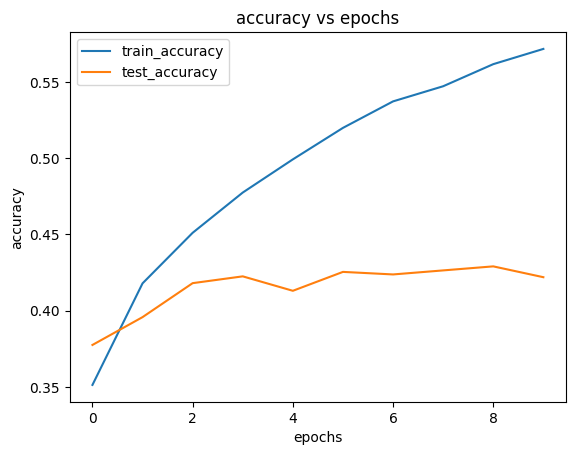

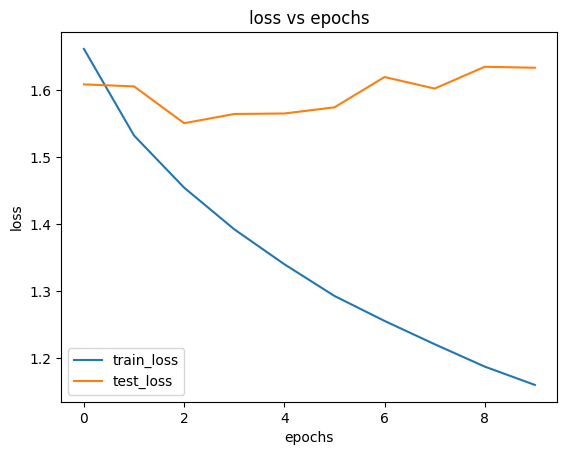

In [ ]:
# accuracyやlossを受け取る
accuracy, loss, val_accuracy, val_loss = history.history.values()

# グラフの出力
fig = plt.figure()
ax = fig.add_subplot()
ax.set_title("accuracy vs epochs") # タイトル
ax.plot(range(epochs), accuracy, label="train_accuracy") # 折れ線グラフ(引数は順にx,y,label)
ax.plot(range(epochs), val_accuracy, label="test_accuracy")# 折れ線グラフ(引数は順にx,y,label)
ax.set_xlabel("epochs") # x軸のラベル
ax.set_ylabel("accuracy") # y軸のラベル
ax.legend() # 折れ線グラフのラベルを表示
plt.show() # グラフの出力

# 上と同じ
fig = plt.figure()
ax = fig.add_subplot()
ax.set_title("loss vs epochs")
ax.plot(range(epochs), loss, label="train_loss")
ax.plot(range(epochs), val_loss, label="test_loss")
ax.set_xlabel("epochs")
ax.set_ylabel("loss")
ax.legend()
plt.show()

5536番目の画像
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step


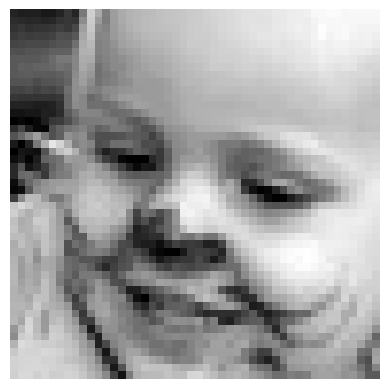

正解のラベル：happy
予測のラベル：angry


In [ ]:
# ランダムで整数を一つ生成
idx = np.random.randint(len(test_images))
print(f"{idx}番目の画像")
# 学習したモデルに画像を入力して推論結果を保存
result = model.predict(test_images[idx][tf.newaxis])

# 画像の見た目を確認
fig = plt.figure()
ax = fig.add_subplot()
ax.imshow(test_images[idx], "gray")
ax.axis("off")
plt.show()

# 正解のラベルとAIが予測したラベルを比べる
print(f"正解のラベル：{number2label[np.argmax(test_labels[idx])]}")
print(f"予測のラベル：{number2label[np.argmax(result)]}")

ポスター用かな

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

# 写真を撮るための関数
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Capture';
        div.appendChild(capture);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // Resize the output to fit the video element.
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        // Wait for Capture to be clicked.
        await new Promise((resolve) => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

In [ ]:
# 写真を撮る
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))
  display(Image(filename))
except Exception as err:
  print(str(err))

<IPython.core.display.Javascript object>

Saved to photo.jpg
name 'Image' is not defined


In [ ]:
# カスケード分類器の読み込み
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# 画像読み込み
image = cv2.imread("photo.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 顔検出
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

# 最初の顔を切り出して表示
for (x, y, w, h) in faces[:1]:
    face = image[y:y+h, x:x+w]
    cv2.imwrite("photo.jpg", face)
    cv2_imshow(face)
    break
else:
    print("顔が見つかりませんでした。")

print("画像の形状を確認", face.shape)

# 画像の読み込み
image = read_and_preprocess("photo.jpg")
# AIの所望する形状に写真をリサイズ
image = tf.image.resize(image, (48, 48))

# モデルのロード
model = tf.keras.models.load_model('base_model.keras')
# 学習したモデルに画像を入力して推論結果を保存
result = model.predict(image[tf.newaxis])

# AIの予測結果
print(f"予測のラベル：{number2label[np.argmax(result)]}")